# Almayra Edgina Rahma

# YouTube: https://youtu.be/KzycLSBJY6g

In [1]:
import pandas as pd

df = pd.read_parquet('1B.parquet')
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [2]:
df['torque'].head(20)

,torque
0,114Nm@ 4000rpm
1,330Nm@ 1800rpm
2,110Nm@ 4800rpm
3,200Nm@ 1750rpm
4,115Nm@ 4000rpm
5,360Nm@ 2000rpm
6,"145@ 4,100(kgm@ rpm)"
7,112Nm@ 4000rpm
8,200Nm@ 1750rpm
9,72Nm@ 4386rpm


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

In [4]:
df.shape

(2000, 18)

In [5]:
df.describe()

,Sales_ID,year,selling_price,km_driven,engine,max_power,seats
count,2000.000000,2000.000000,1998.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,4094.438500,2014.544000,6500.861947,68850.914500,1463.207500,91.872012,5.40800
std,2365.032531,22.593966,8322.011983,50097.963956,500.728476,36.126674,0.94973
min,1.000000,1999.000000,350.000000,0.000000,624.000000,-100.000000,4.00000
25%,2009.500000,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.00000
50%,4070.500000,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.00000
75%,6198.500000,2017.000000,6750.000000,90041.250000,1582.000000,102.000000,5.00000
max,8127.000000,3011.000000,100000.000000,475000.000000,3604.000000,400.000000,14.00000


In [6]:
df=df.drop(columns=['Sales_ID'])

# Preprocessing

In [7]:
df = df.dropna()
df = df.reset_index(drop=True)

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)

data torque punya format yang tidak wajar, harusnya bisa dipisah jadi 2 kolom Nm dan Rpm dengan regex, tp periksa apa sudah konsisten

In [10]:
regex_check = df[~df['torque'].str.contains(r'Nm.*rpm|kgm.*rpm', case=False, na=False)]
print(regex_check[['torque']])

                torque
68               400Nm
115              400Nm
326   190Nm@ 2000-3000
346              400Nm
533      135.4Nm@ 2500
538              400Nm
846              400Nm
851              400Nm
996              400Nm
1093             400Nm
1581             400Nm
1657             400Nm
1717             400Nm
1788             400Nm


In [11]:
len(regex_check)

14

In [12]:
df['torque']

,torque
0,114Nm@ 4000rpm
1,330Nm@ 1800rpm
2,110Nm@ 4800rpm
3,200Nm@ 1750rpm
4,115Nm@ 4000rpm
...,...
1993,171.6Nm@ 1500-4000rpm
1994,320Nm@ 1800-2800rpm
1995,113Nm@ 4200rpm
1996,224Nm@ 4000rpm


In [13]:
import re
import numpy as np
import pandas as pd

def clean_torque(text):
    #hilangin koma, spasi, ubah ke huruf kecil
    text = str(text).lower().replace(',', '')

    #ambil angka yg muncul
    torque_match = re.search(r'(\d+\.?\d*)', text)
    torque = float(torque_match.group(1)) if torque_match else np.nan

    #klo kgm convert dulu
    if 'kgm' in text and pd.notna(torque):
        torque = torque * 9.80665

    #ekstrak rpm setelah lambang @ dan cek bila dikasi range dgn lambang -
    range_match = re.search(r'(?:@|at)[^\d]*(\d+)[-\s~]+(\d+)', text)

    if range_match:
        rpm = (float(range_match.group(1)) + float(range_match.group(2))) / 2
    else:
        #klo bukan range maka ambil angkanya aja
        single_match = re.search(r'(?:@|at)[^\d]*(\d+)', text)
        if single_match:
            rpm = float(single_match.group(1))
        else:
            #kli tidak ada @ maka cari lambang rpm
            rpm_fallback = re.search(r'(\d+)\s*rpm', text)
            rpm = float(rpm_fallback.group(1)) if rpm_fallback else np.nan

    return pd.Series([torque, rpm])

# pisah jadi 2 dataframe
df[['torque_Nm', 'rpm_val']] = df['torque'].apply(clean_torque)

In [14]:
df[['torque_Nm', 'rpm_val']].head()

,torque_Nm,rpm_val
0,114.0,4000.0
1,330.0,1800.0
2,110.0,4800.0
3,200.0,1750.0
4,115.0,4000.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 1997
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1996 non-null   object 
 1   year               1996 non-null   int64  
 2   selling_price      1996 non-null   float64
 3   km_driven          1996 non-null   int64  
 4   Region             1996 non-null   object 
 5   State or Province  1996 non-null   object 
 6   City               1996 non-null   object 
 7   fuel               1996 non-null   object 
 8   seller_type        1996 non-null   object 
 9   transmission       1996 non-null   object 
 10  owner              1996 non-null   object 
 11  mileage            1996 non-null   object 
 12  engine             1996 non-null   int64  
 13  max_power          1996 non-null   float64
 14  torque             1996 non-null   object 
 15  seats              1996 non-null   int64  
 16  sold               1996 non-n

In [16]:
df = df.drop(columns=['torque'])

## Cek Konsistensi Tipe Data


mileage harusnya string

In [17]:
#x_train['mileage']=x_train['mileage'].astype(np.float64)

ada data anomali yg membuat jd datatype object

In [18]:
df['mileage'] = df['mileage'].str.replace(',', '.', regex=False).astype(float)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 1997
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1996 non-null   object 
 1   year               1996 non-null   int64  
 2   selling_price      1996 non-null   float64
 3   km_driven          1996 non-null   int64  
 4   Region             1996 non-null   object 
 5   State or Province  1996 non-null   object 
 6   City               1996 non-null   object 
 7   fuel               1996 non-null   object 
 8   seller_type        1996 non-null   object 
 9   transmission       1996 non-null   object 
 10  owner              1996 non-null   object 
 11  mileage            1994 non-null   float64
 12  engine             1996 non-null   int64  
 13  max_power          1996 non-null   float64
 14  seats              1996 non-null   int64  
 15  sold               1996 non-null   object 
 16  torque_Nm          1996 non-n

#Target

In [20]:
df['selling_price']

,selling_price
0,4500.00
1,4000.00
2,8199.99
3,6750.00
4,6750.00
...,...
1993,11250.00
1994,12500.00
1995,4500.00
1996,4500.00


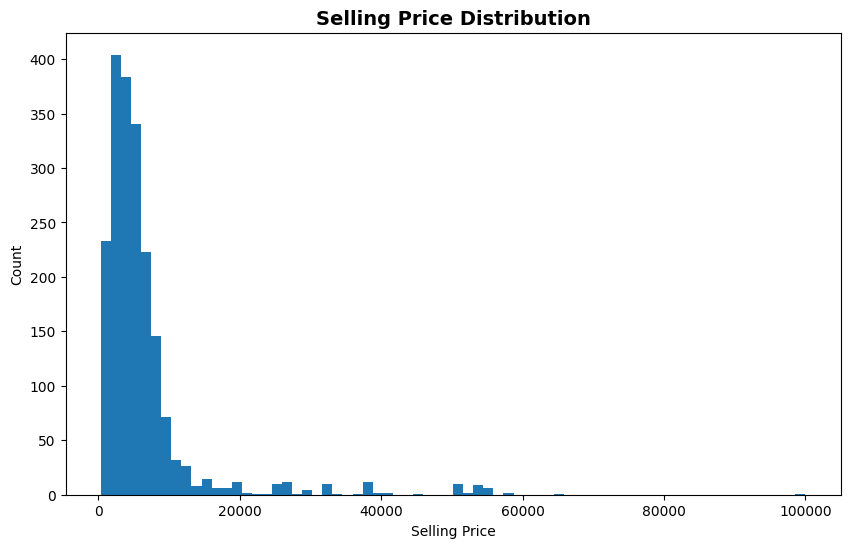

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['selling_price'], bins=70)
plt.title('Selling Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.show()

# Exploratory Data Analysis

###Numerik

In [22]:
num = df.select_dtypes(include=['int64', 'float64'])

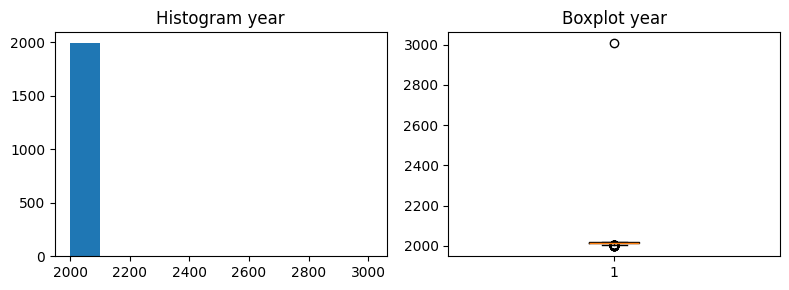

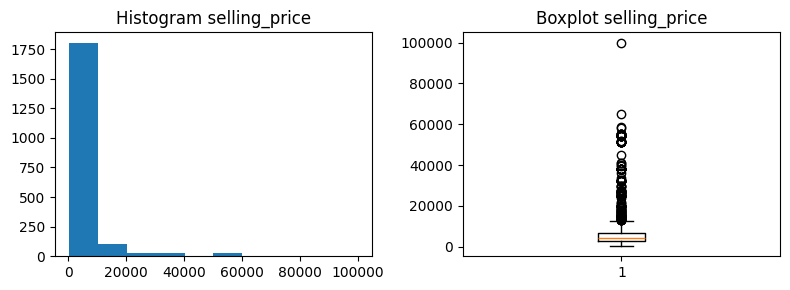

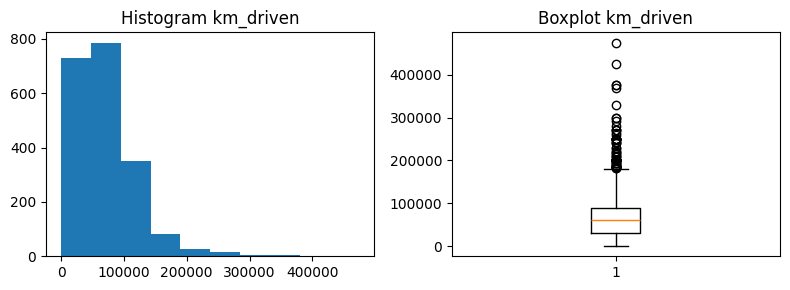

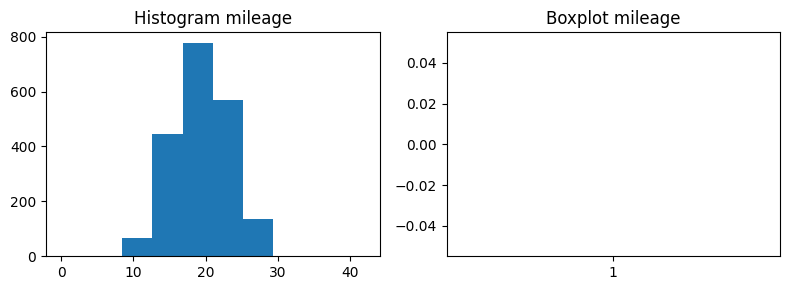

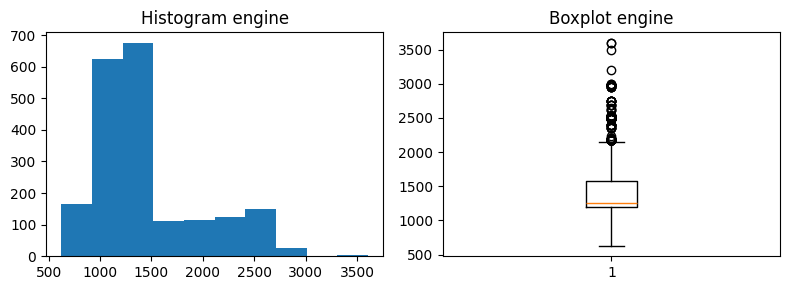

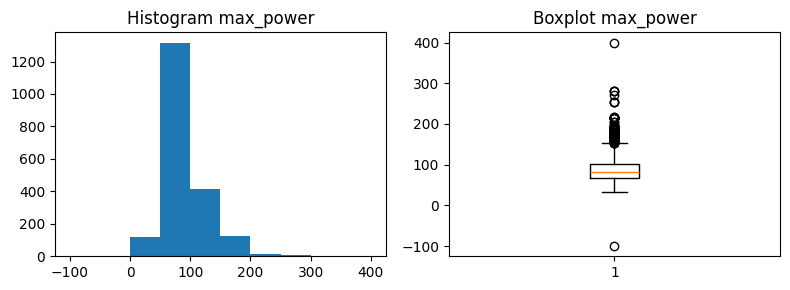

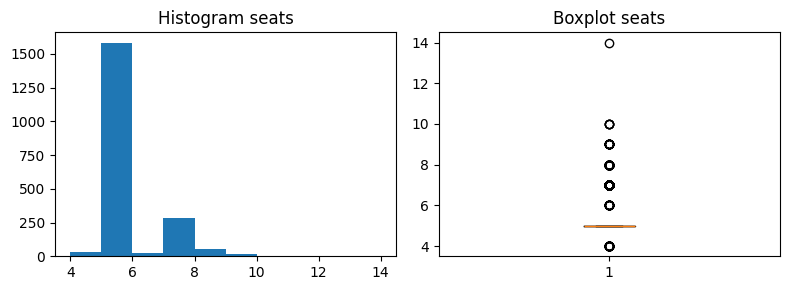

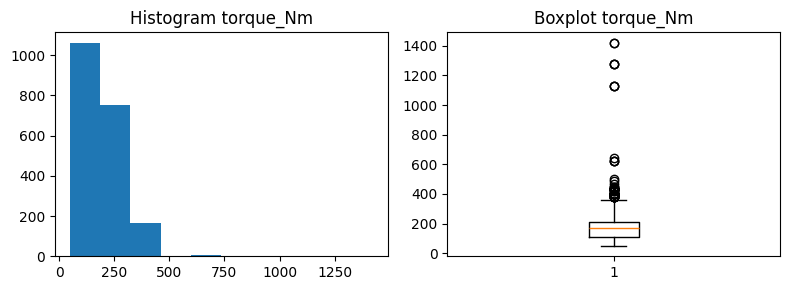

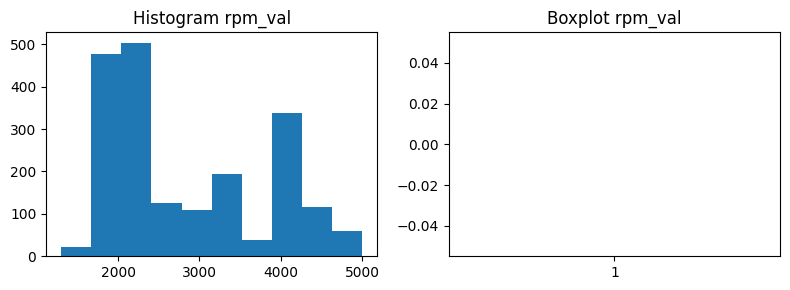

In [23]:
for col in num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].hist(df[col], bins=10)
    axes[0].set_title(f'Histogram {col}')
    axes[1].boxplot(df[col], vert=True)
    axes[1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

In [24]:
import pandas as pd
import numpy as np

def outlier_summary(df):
    num_cols = df.select_dtypes(include=[np.number]).columns

    results = []

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        count_outliers = outliers.shape[0]
        total = df[col].shape[0]
        percentage = (count_outliers / total) * 100

        results.append({
            'Feature': col,
            'Total Data': total,
            'Outlier Count': count_outliers,
            'Outlier Percentage (%)': round(percentage, 2)
        })

    return pd.DataFrame(results).sort_values(by='Outlier Percentage (%)', ascending=False)



In [25]:
outlie = outlier_summary(df)
outlie

,Feature,Total Data,Outlier Count,Outlier Percentage (%)
6,seats,1996,415,20.79
4,engine,1996,301,15.08
1,selling_price,1996,143,7.16
5,max_power,1996,135,6.76
7,torque_Nm,1996,88,4.41
2,km_driven,1996,61,3.06
0,year,1996,31,1.55
3,mileage,1996,3,0.15
8,rpm_val,1996,0,0.00


In [26]:
num.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_Nm,rpm_val
count,1996.000000,1996.000000,1996.000000,1994.000000,1996.000000,1996.000000,1996.000000,1996.000000,1984.000000
mean,2014.545090,6494.600286,68744.713427,19.433887,1462.316132,91.844486,5.407816,181.305574,2884.597278
std,22.616437,8320.662825,49974.828126,3.960117,500.140232,36.129822,0.949881,111.595498,956.148996
min,1999.000000,350.000000,0.000000,0.000000,624.000000,-100.000000,4.000000,48.000000,1300.000000
25%,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,2000.000000
50%,2015.000000,4500.000000,60000.000000,19.335000,1248.000000,82.000000,5.000000,170.000000,2400.000000
75%,2017.000000,6750.000000,90000.000000,22.320000,1582.000000,102.000000,5.000000,213.000000,4000.000000
max,3011.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000,1421.964250,5000.000000


Terdapat beberapa data yang inkonsisten atau memiliki nilai ekstrim pada data numerik

* mileage & km driven tidak mungkin < 0 karena mobil bekas
* year tidak mungkin > 2026
* max_power gk mungkin negatif
* nilai outlier torque nm sangat tinggi
* proporsi outlier seats tinggi

In [27]:
df = df[df['year'] <= 2026]
df = df[df['max_power'] > 0]
df = df[df['km_driven'] > 0]
df = df[df['mileage'] > 0]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1990 entries, 0 to 1997
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1990 non-null   object 
 1   year               1990 non-null   int64  
 2   selling_price      1990 non-null   float64
 3   km_driven          1990 non-null   int64  
 4   Region             1990 non-null   object 
 5   State or Province  1990 non-null   object 
 6   City               1990 non-null   object 
 7   fuel               1990 non-null   object 
 8   seller_type        1990 non-null   object 
 9   transmission       1990 non-null   object 
 10  owner              1990 non-null   object 
 11  mileage            1990 non-null   float64
 12  engine             1990 non-null   int64  
 13  max_power          1990 non-null   float64
 14  seats              1990 non-null   int64  
 15  sold               1990 non-null   object 
 16  torque_Nm          1990 non-n

### Objek

In [29]:
objek = df.select_dtypes(include=['object'])

In [30]:
for col in objek.columns:
  print(objek[col].value_counts())
  print("--------------------------------------")

name
Maruti        576
Hyundai       359
Mahindra      183
Tata          182
Toyota        120
Ford          115
Honda         114
Renault        54
Chevrolet      49
Volkswagen     45
Skoda          35
BMW            27
Volvo          22
Datsun         21
Nissan         19
Jaguar         16
Mercedes       12
Lexus          10
Fiat            8
Jeep            7
Audi            7
Isuzu           3
Force           2
Mitsubishi      1
Land            1
Daewoo          1
MG              1
Name: count, dtype: int64
--------------------------------------
Region
Central    603
West       505
East       479
South      401
N/A          2
Name: count, dtype: int64
--------------------------------------
State or Province
California              222
Texas                   135
New York                121
Illinois                119
Florida                 107
Michigan                 82
Washington               78
Ohio                     74
Pennsylvania             65
Indiana                  60

In [31]:
df['transmission'].unique()

array(['Manual', 'Automatic', ''], dtype=object)

In [32]:
dfc=df[df['Region']=='N/A']
dfc

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,rpm_val
727,Maruti,2013,6000.0,60000,N/A,Illinois,Chicago,Diesel,Individual,Manual,First_Owner,20.77,1248,88.8,7,Y,200.0,1750.0
1467,Mahindra,2013,3000.0,120000,N/A,Illinois,Chicago,Diesel,Individual,Manual,Second_Owner,17.21,1493,100.0,7,Y,240.0,2200.0


In [33]:
df['Region']=df['Region'].replace({'N/A': 'Central'})

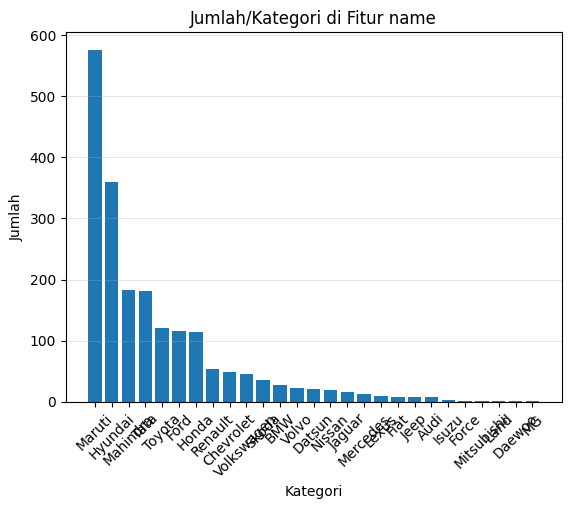

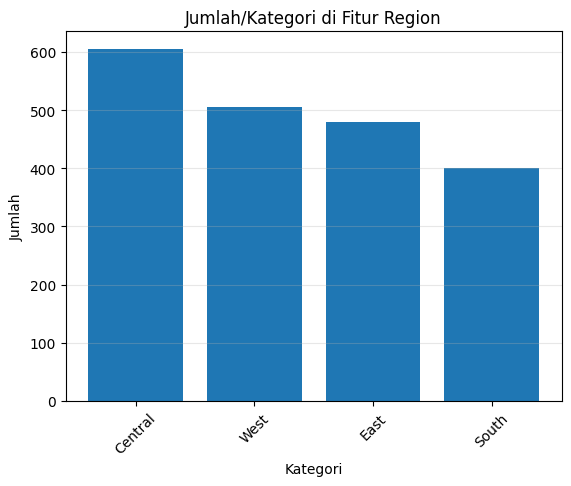

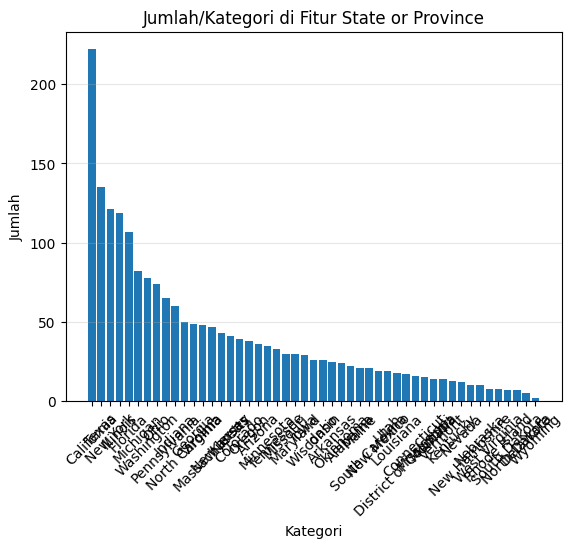

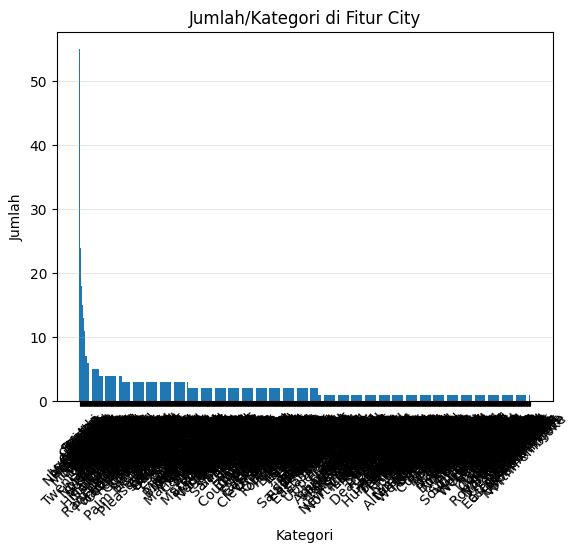

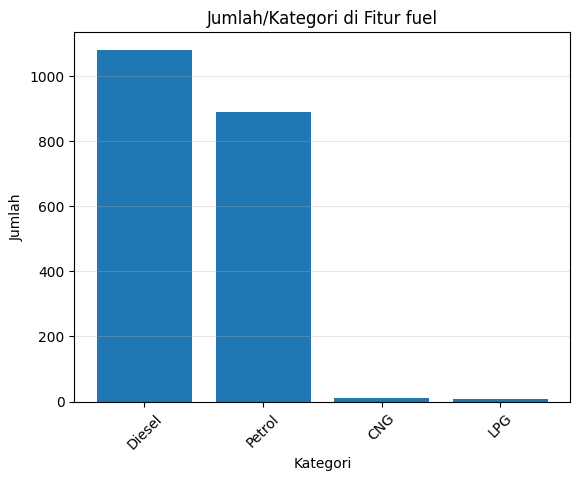

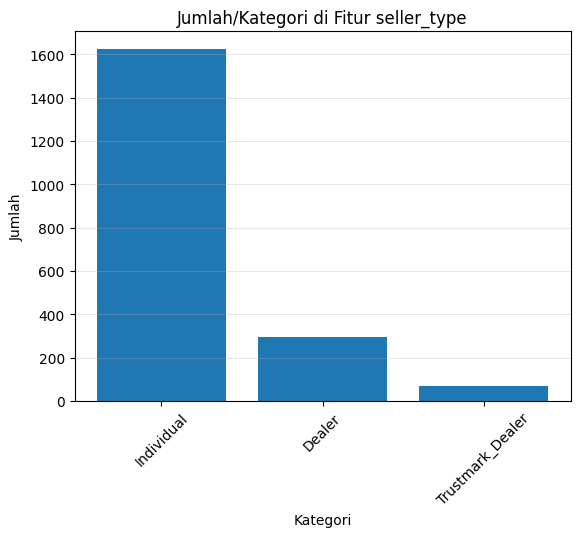

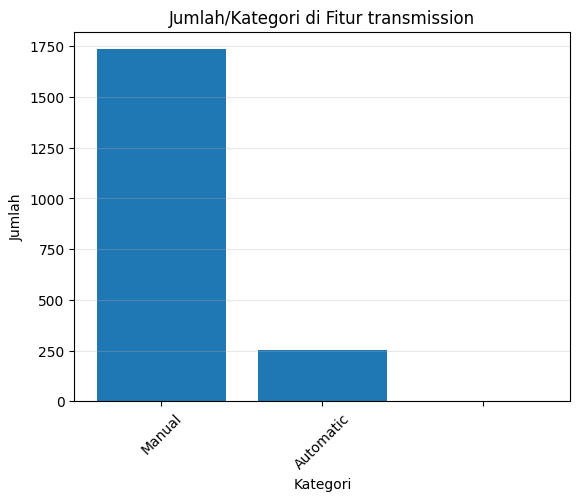

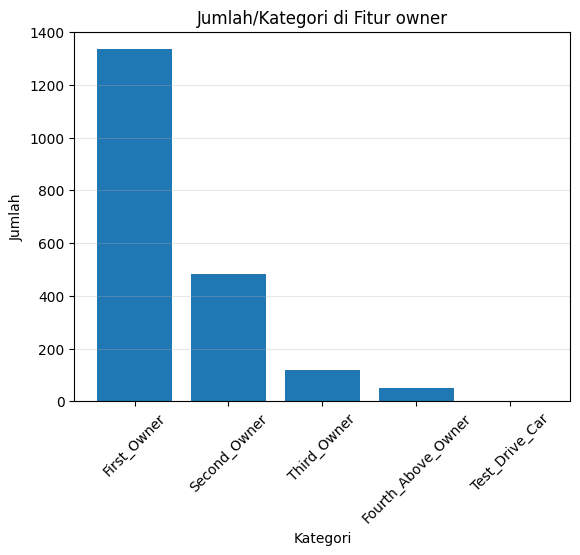

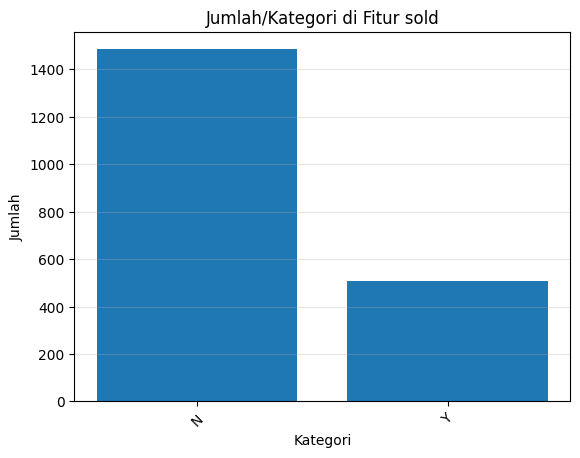

In [34]:
for col in objek.columns:

  counts = df[col].value_counts()
  plt.bar(counts.index, counts.values)
  plt.title(f"Jumlah/Kategori di Fitur {col}")
  plt.xlabel("Kategori")
  plt.ylabel("Jumlah")
  plt.grid(axis='y', alpha=0.3)
  plt.xticks(rotation=45)
  plt.show()

In [35]:
df = df.drop(columns=['City'])

## Correlation Analysis

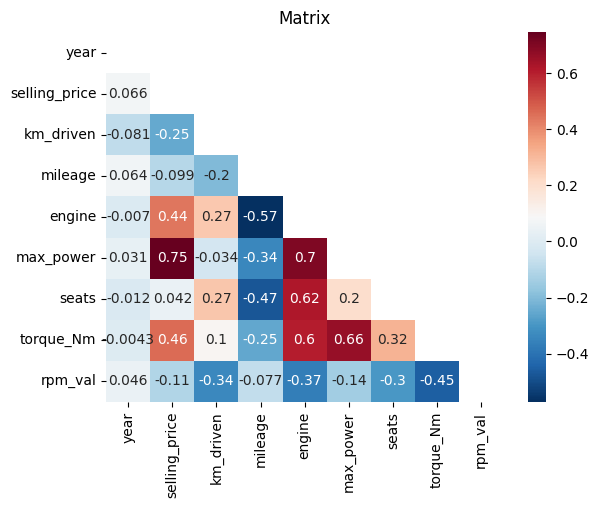

In [36]:
import seaborn as sns
corr = num.corr()
corrl = corr.loc[corr.index, corr.index]
mask1=np.triu(np.ones_like(corrl, dtype=bool))
sns.heatmap(corr.loc[corr.index, corr.index],cmap='RdBu_r',annot=True,mask=mask1)
plt.title("Matrix")
plt.show()



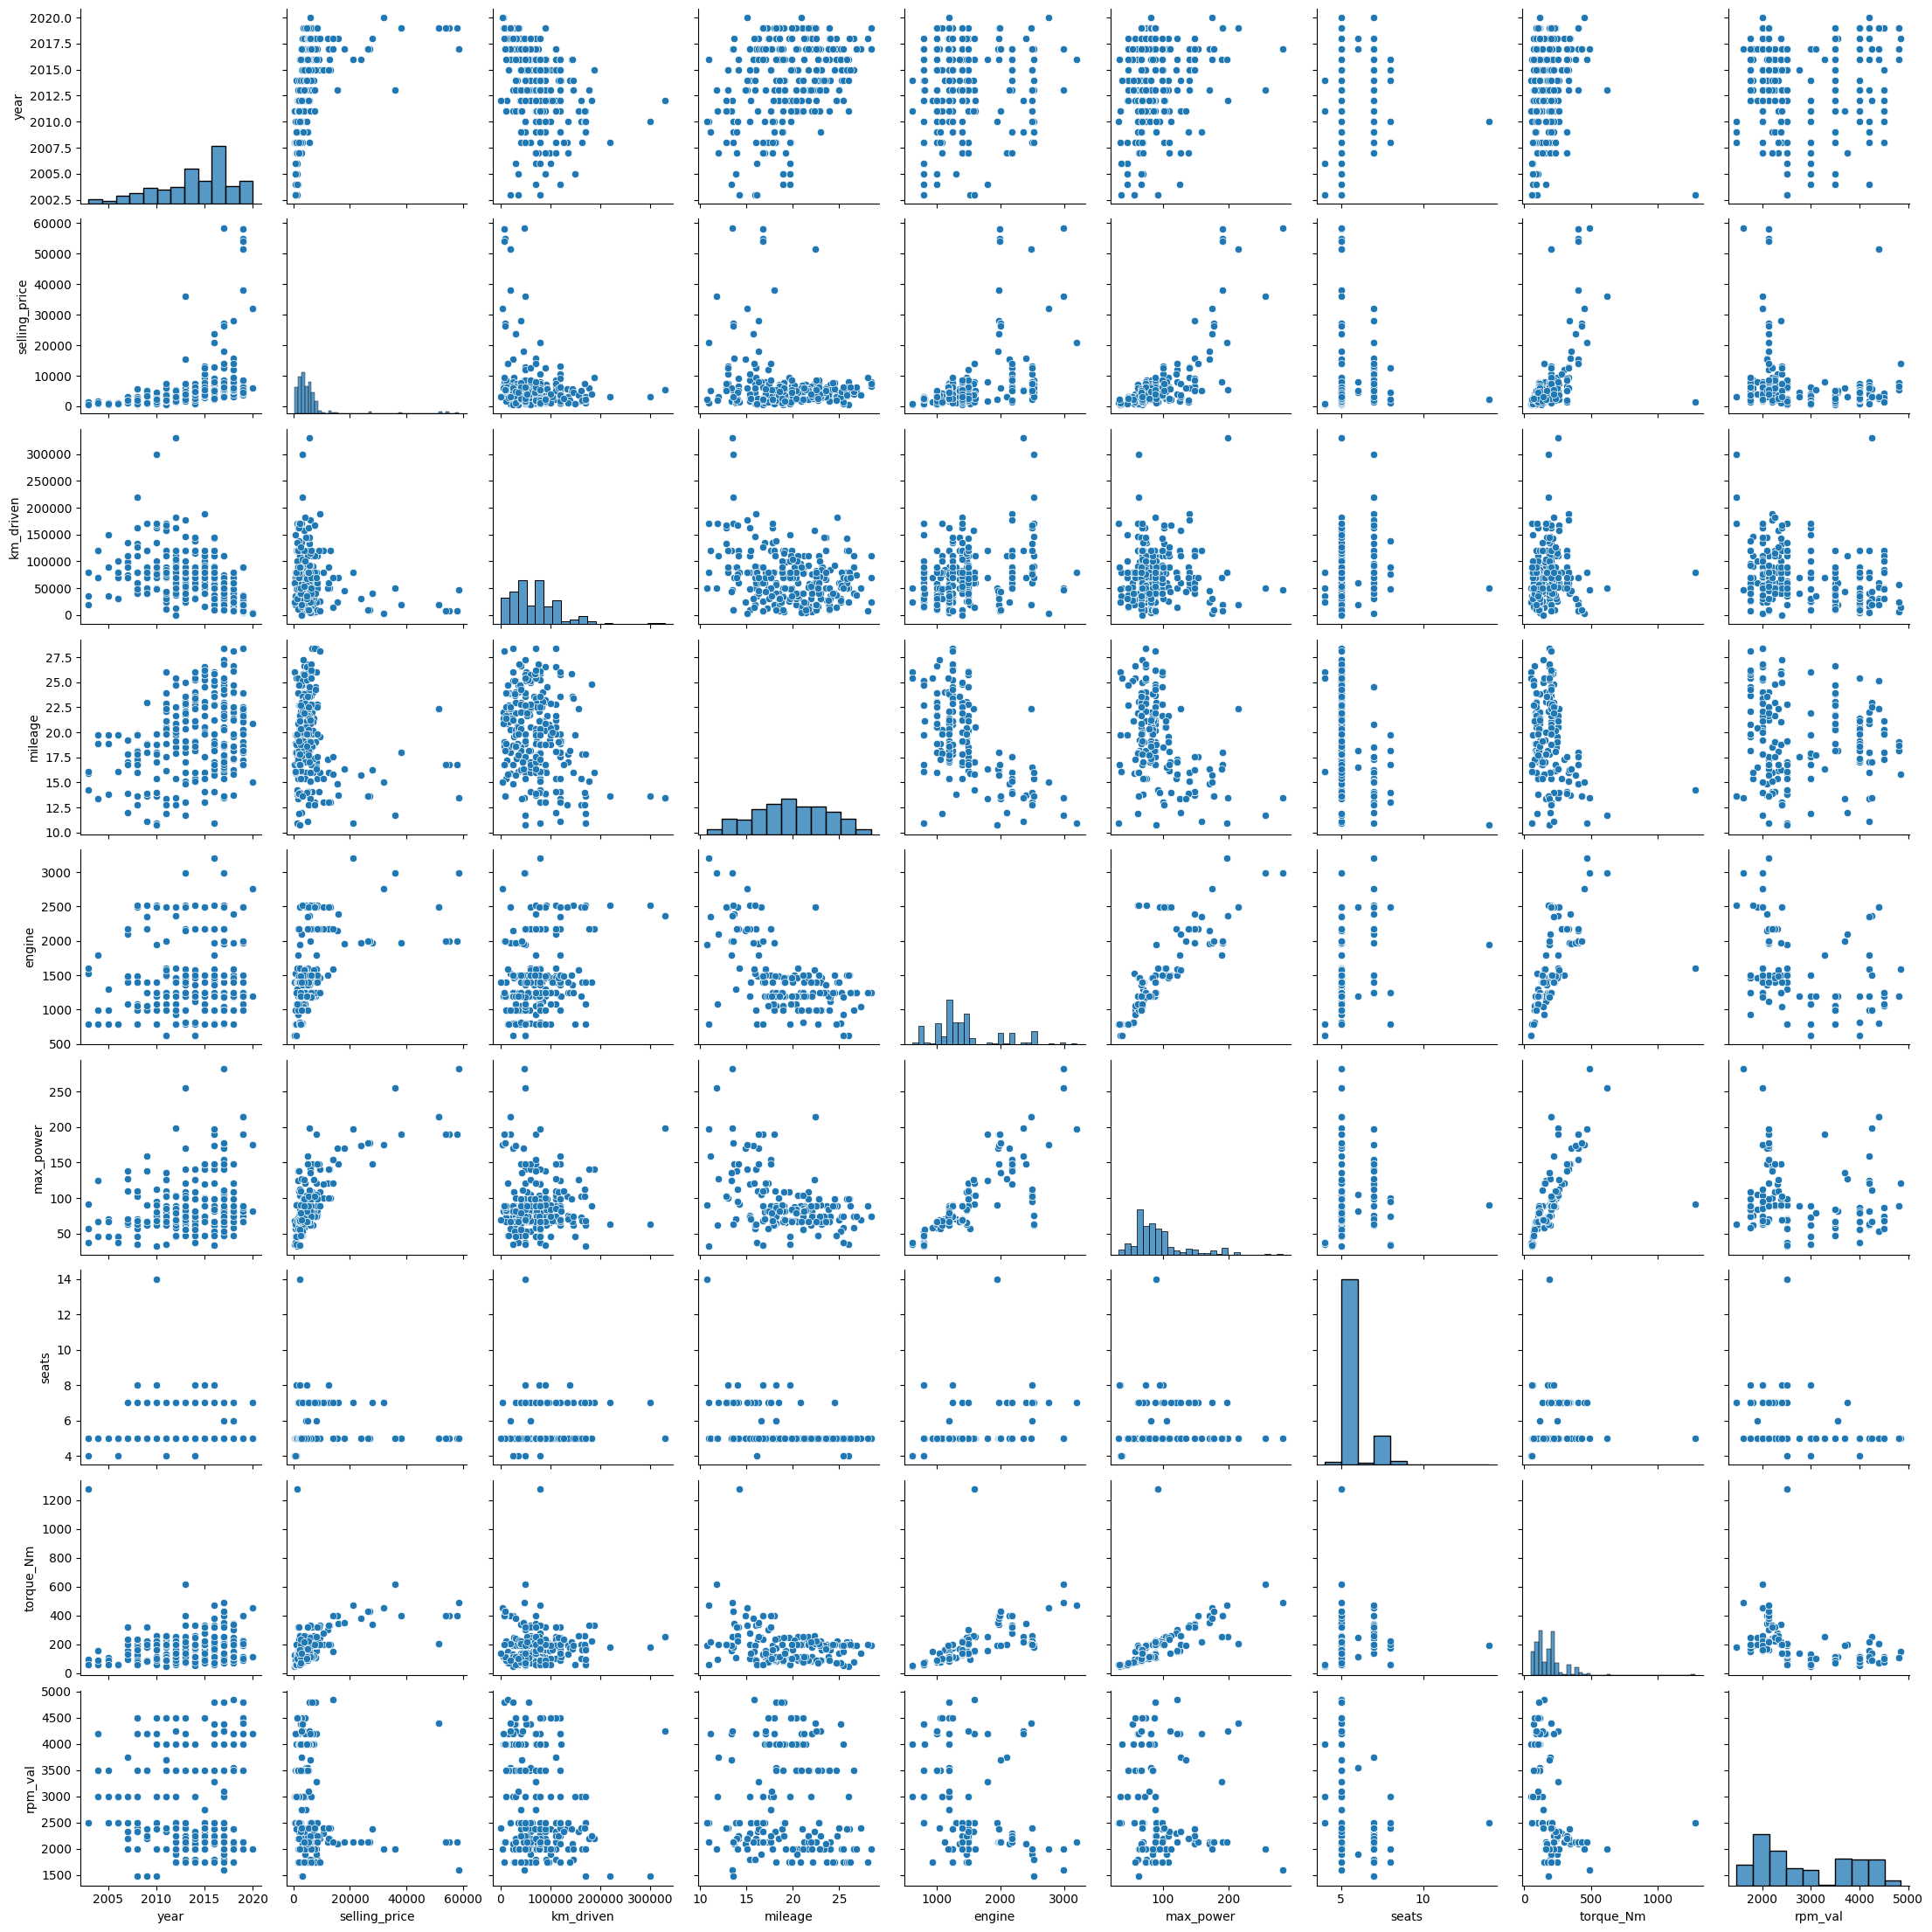

In [37]:
sns.pairplot(num.sample(300))
plt.show()

In [38]:
objek=['name', 'Region', 'State or Province', 'fuel', 'seller_type',
       'transmission', 'owner', 'sold']

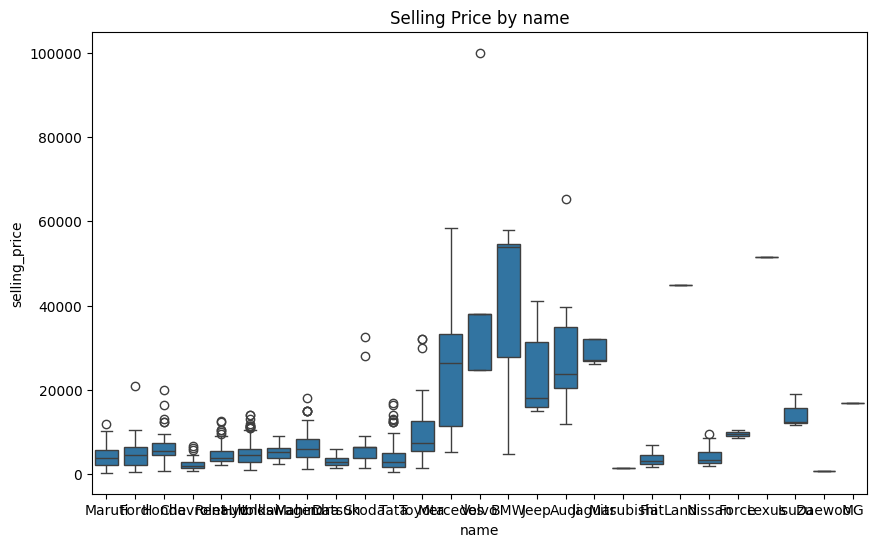

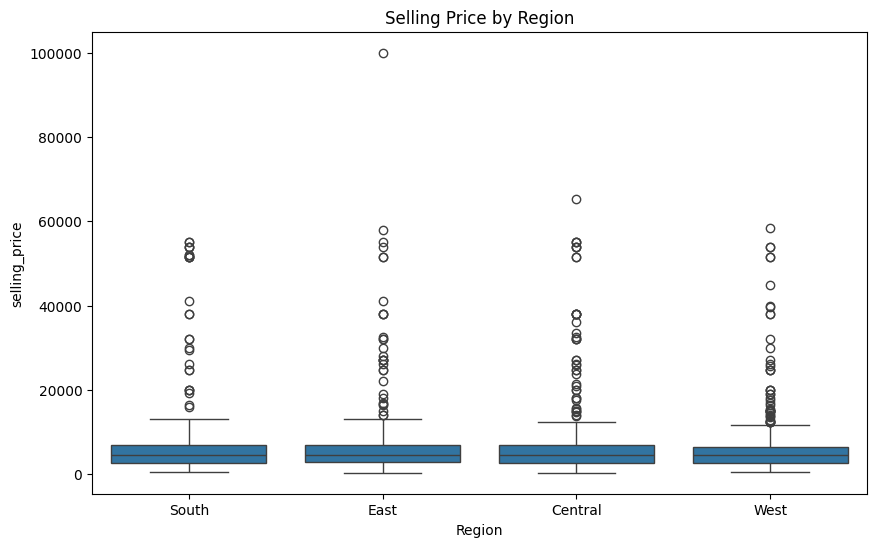

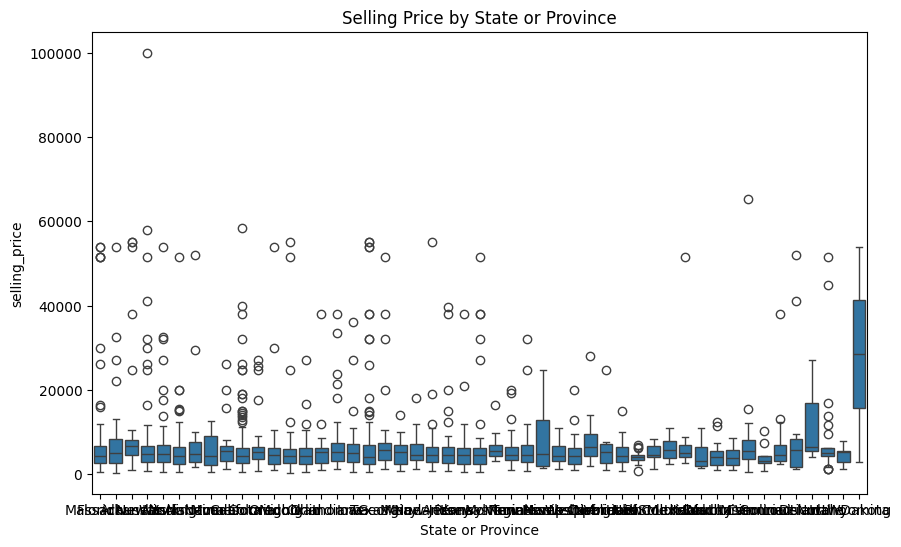

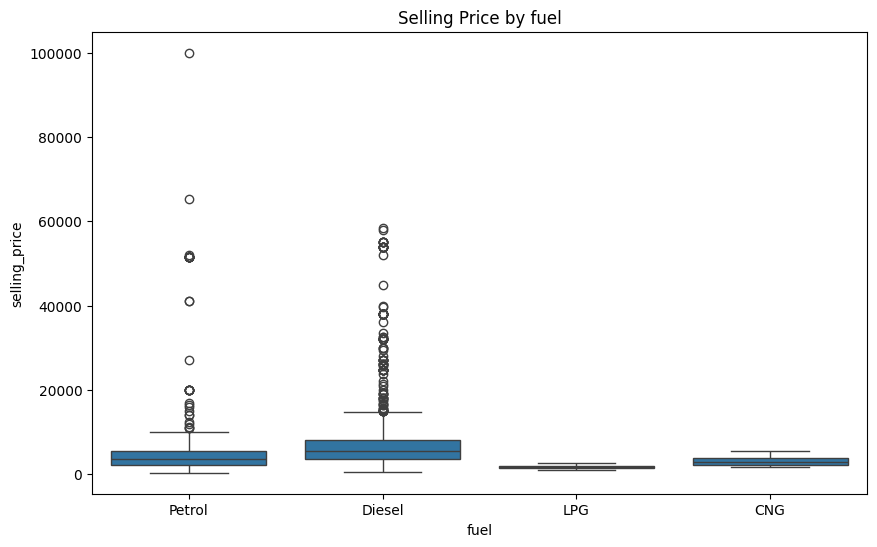

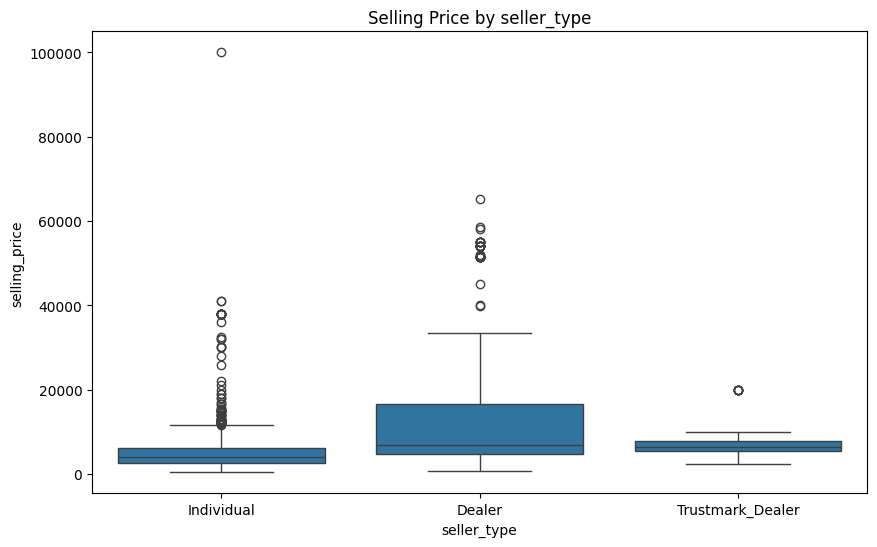

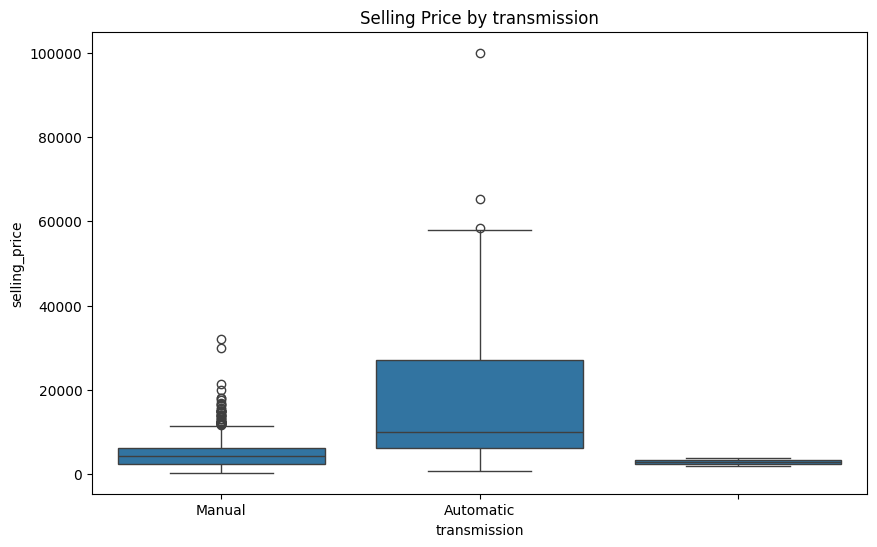

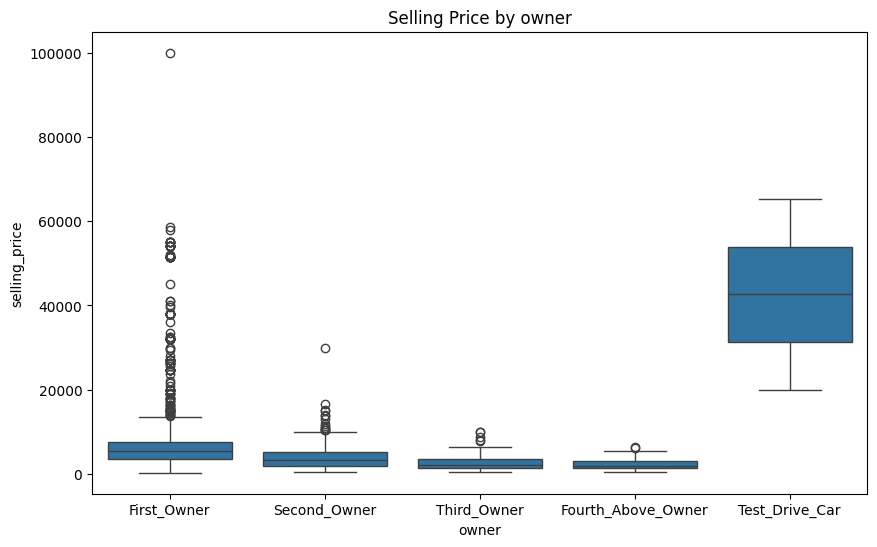

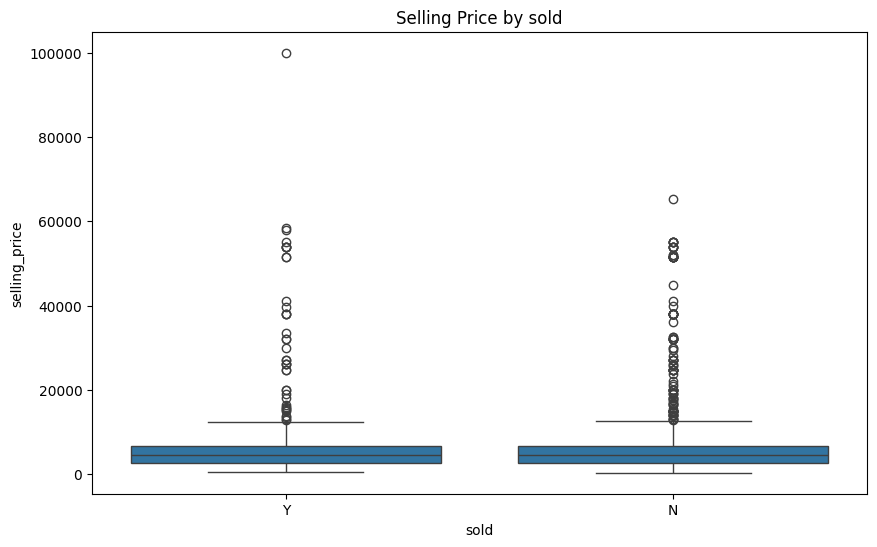

In [39]:
for c in objek:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=c, y='selling_price', data=df)
  plt.title(f'Selling Price by {c}')
  plt.show()

# Split

In [40]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['selling_price'])
y=df['selling_price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Impute & normalization

In [41]:
x_train['transmission']=x_train['transmission'].replace({'': 'Manual'})
x_test['transmission']=x_test['transmission'].replace({'': 'Manual'})

In [42]:
x_train['rpm_val']= x_train['rpm_val'].fillna(x_train['rpm_val'].median())
x_test['rpm_val']= x_test['rpm_val'].fillna(x_test['rpm_val'].median())

In [43]:
x_train['mileage']= x_train['mileage'].fillna(x_train['mileage'].median())
x_test['mileage']= x_test['mileage'].fillna(x_test['mileage'].median())

In [44]:
x_train['km_driven']=np.log1p(x_train['km_driven'])
x_test['km_driven']=np.log1p(x_test['km_driven'])

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1990 entries, 0 to 1997
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1990 non-null   object 
 1   year               1990 non-null   int64  
 2   selling_price      1990 non-null   float64
 3   km_driven          1990 non-null   int64  
 4   Region             1990 non-null   object 
 5   State or Province  1990 non-null   object 
 6   fuel               1990 non-null   object 
 7   seller_type        1990 non-null   object 
 8   transmission       1990 non-null   object 
 9   owner              1990 non-null   object 
 10  mileage            1990 non-null   float64
 11  engine             1990 non-null   int64  
 12  max_power          1990 non-null   float64
 13  seats              1990 non-null   int64  
 14  sold               1990 non-null   object 
 15  torque_Nm          1990 non-null   float64
 16  rpm_val            1978 non-n

In [46]:
y_train=np.log1p(y_train)
y_test=np.log1p(y_test)

## Winsorise outlier

In [47]:
from scipy.stats.mstats import winsorize

x_train['torque_Nm'] = winsorize(x_train['torque_Nm'], limits=[0.05, 0.05])
x_test['torque_Nm'] = winsorize(x_test['torque_Nm'], limits=[0.05, 0.05])
x_train['seats'] = winsorize(x_train['seats'], limits=[0.05, 0.05])
x_test['seats'] = winsorize(x_test['seats'], limits=[0.05, 0.05])

#Feature Engineering

## Cek Outlier

feature dgn outlier > 3% pakai robust scaler
yang lain pk standard scaler

## Scaling

In [48]:
x_train.columns

Index(['name', 'year', 'km_driven', 'Region', 'State or Province', 'fuel',
       'seller_type', 'transmission', 'owner', 'mileage', 'engine',
       'max_power', 'seats', 'sold', 'torque_Nm', 'rpm_val'],
      dtype='object')

In [49]:
num.columns

Index(['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power',
       'seats', 'torque_Nm', 'rpm_val'],
      dtype='object')

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder

many_outlie = ['seats', 'engine', 'max_power','torque_Nm']
less_outlie = ['km_driven', 'year','mileage','rpm_val']

scaler1 = StandardScaler()
x_train[less_outlie] = scaler1.fit_transform(x_train[less_outlie])
x_test[less_outlie] = scaler1.transform(x_test[less_outlie])

scaler2 = RobustScaler()
x_train[many_outlie] = scaler2.fit_transform(x_train[less_outlie])
x_test[many_outlie] = scaler2.transform(x_test[less_outlie])


## Encoding

In [51]:
for col in objek:
  print(f'Feature Name: {col}')
  print(f'number of unique Values: {df[col].nunique()}')
  print("+++")
  print(df[col].value_counts())
  print("--------------------------------------")

Feature Name: name
number of unique Values: 27
+++
name
Maruti        576
Hyundai       359
Mahindra      183
Tata          182
Toyota        120
Ford          115
Honda         114
Renault        54
Chevrolet      49
Volkswagen     45
Skoda          35
BMW            27
Volvo          22
Datsun         21
Nissan         19
Jaguar         16
Mercedes       12
Lexus          10
Fiat            8
Jeep            7
Audi            7
Isuzu           3
Force           2
Mitsubishi      1
Land            1
Daewoo          1
MG              1
Name: count, dtype: int64
--------------------------------------
Feature Name: Region
number of unique Values: 4
+++
Region
Central    605
West       505
East       479
South      401
Name: count, dtype: int64
--------------------------------------
Feature Name: State or Province
number of unique Values: 49
+++
State or Province
California              222
Texas                   135
New York                121
Illinois                119
Florida        

In [52]:
#freq
x_train['name'] = x_train['name'].map(x_train['name'].value_counts(normalize=True))
x_train['State or Province'] = x_train['State or Province'].map(x_train['State or Province'].value_counts(normalize=True))

x_test['name'] = x_test['name'].map(x_test['name'].value_counts(normalize=True))
x_test['State or Province'] = x_test['State or Province'].map(x_test['State or Province'].value_counts(normalize=True))


# Binary
x_train['transmission'] = x_train['transmission'].map({'Manual': 0, 'Automatic': 1})
x_test['transmission'] = x_test['transmission'].map({'Manual': 0, 'Automatic': 1})
x_train['sold'] = x_train['sold'].map({'Y': 1, 'N': 0})
x_test['sold'] = x_test['sold'].map({'Y': 1, 'N': 0})

# Ordinal
owner_map = {
    'First_Owner': 1,
    'Second_Owner': 2,
    'Third_Owner': 3,
    'Fourth_Above_Owner': 4,
    'Test_Drive_Car': 0
}

x_train['owner'] = x_train['owner'].map(owner_map)
x_test['owner'] = x_test['owner'].map(owner_map)

# One-hot
x_train = pd.get_dummies(x_train, columns=['fuel', 'seller_type', 'Region'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['fuel', 'seller_type', 'Region'], drop_first=True)

In [53]:
x_train.head()

,name,year,km_driven,State or Province,transmission,owner,mileage,engine,max_power,seats,...,torque_Nm,rpm_val,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark_Dealer,Region_East,Region_South,Region_West
241,0.290201,1.074143,0.336782,0.012563,1,1,0.651540,0.6,0.469314,0.145835,...,0.900,1.403830,False,False,True,False,False,True,False,False
811,0.090452,-0.263076,0.489597,0.012563,0,1,-0.893619,-0.4,-0.620939,0.277863,...,-0.465,-1.476581,True,False,False,True,False,True,False,False
1463,0.290201,-1.065408,-0.204446,0.062186,0,1,-0.141505,-1.0,-0.090253,-0.321772,...,0.550,0.665263,False,False,True,True,False,True,False,False
1918,0.064698,-0.263076,0.480166,0.003769,0,2,-1.653408,-0.4,-1.157040,0.269715,...,0.000,-0.495342,True,False,False,False,True,False,False,False
1957,0.064698,-0.530520,1.278384,0.039573,0,4,-1.702014,-0.6,-1.191336,0.959354,...,0.000,-0.495342,True,False,False,True,False,False,False,True


In [54]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1592 entries, 241 to 1130
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          1592 non-null   float64
 1   year                          1592 non-null   float64
 2   km_driven                     1592 non-null   float64
 3   State or Province             1592 non-null   float64
 4   transmission                  1592 non-null   int64  
 5   owner                         1592 non-null   int64  
 6   mileage                       1592 non-null   float64
 7   engine                        1592 non-null   float64
 8   max_power                     1592 non-null   float64
 9   seats                         1592 non-null   float64
 10  sold                          1592 non-null   int64  
 11  torque_Nm                     1592 non-null   float64
 12  rpm_val                       1592 non-null   float64
 13  fuel_D

1.B.  Buatlah 1 baseline model. Semua hidden layer wajib
menggunakan activation function bernama ReLU dan memiliki jumlah neuron minimal 2 kali lipat dari
dimensi input data. Model anda harus memiliki minimal 2 hidden layer. Lakukan training pada model
tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

# Modelling Using Keras - Baseline Model

In [55]:
x_train.shape

(1592, 21)

neuron minimal 2x21 = 42

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
model1 = Sequential([Dense(64, activation='relu', input_shape=(21,)),
                    Dense(42, activation='relu'),
                    Dense(1, activation='relu')])
print(model1.summary())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,181 (16.33 KB)

 Trainable params: 4,181 (16.33 KB)

 Non-trainable params: 0 (0.00 B)

None


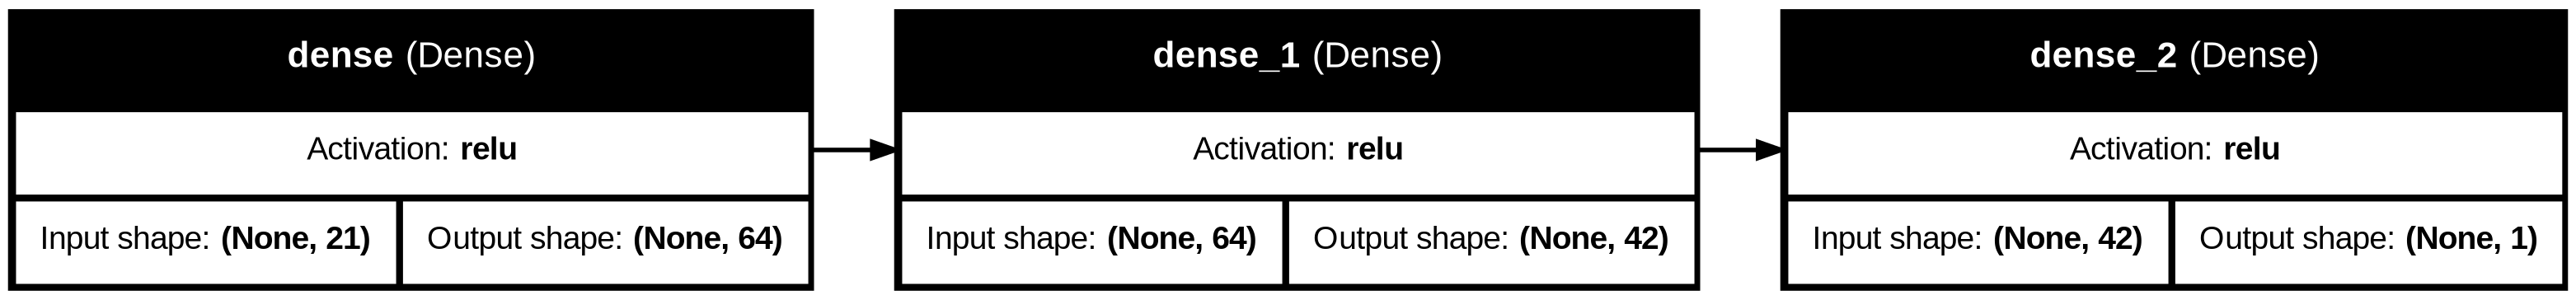

In [57]:
from tensorflow.keras.utils import plot_model

plot_model(model1,show_shapes=True,show_layer_names=True,
           show_layer_activations=True,rankdir='LR')

## Training

In [58]:
model1.compile(optimizer='sgd',loss='mse',metrics=['mae'])

history1 = model1.fit(x_train,y_train,epochs=20,batch_size=30, validation_split=0.125, verbose=1)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1880 - mae: 1.5678 - val_loss: 0.8171 - val_mae: 0.7350
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5827 - mae: 0.5922 - val_loss: 0.3563 - val_mae: 0.4669
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3850 - mae: 0.4819 - val_loss: 0.2835 - val_mae: 0.4185
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3059 - mae: 0.4287 - val_loss: 0.2538 - val_mae: 0.3993
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 - mae: 0.4018 - val_loss: 0.2162 - val_mae: 0.3607
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2263 - mae: 0.3644 - val_loss: 0.2658 - val_mae: 0.4090
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2119 - mae: 0.3531 - val_loss: 0.2309 - val_mae: 0.3815
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2079 - mae: 0.3553 - val_loss: 0.1875 - val_mae: 0.3373
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1977 - mae: 

## Evaluation

In [59]:
y_pred = model1.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.38056768500687327
MSE: 0.2373559862111394
RMSE: 0.4871919398051854
R2 Score: 0.5521153236779244


# Modified Modelling

In [61]:
model2 = Sequential([Dense(64, activation='elu', input_shape=(21,)),
                    Dense(42, activation='relu'),
                    Dense(1, activation='linear')])
print(model2.summary())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 42)             │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,181 (16.33 KB)

 Trainable params: 4,181 (16.33 KB)

 Non-trainable params: 0 (0.00 B)

None


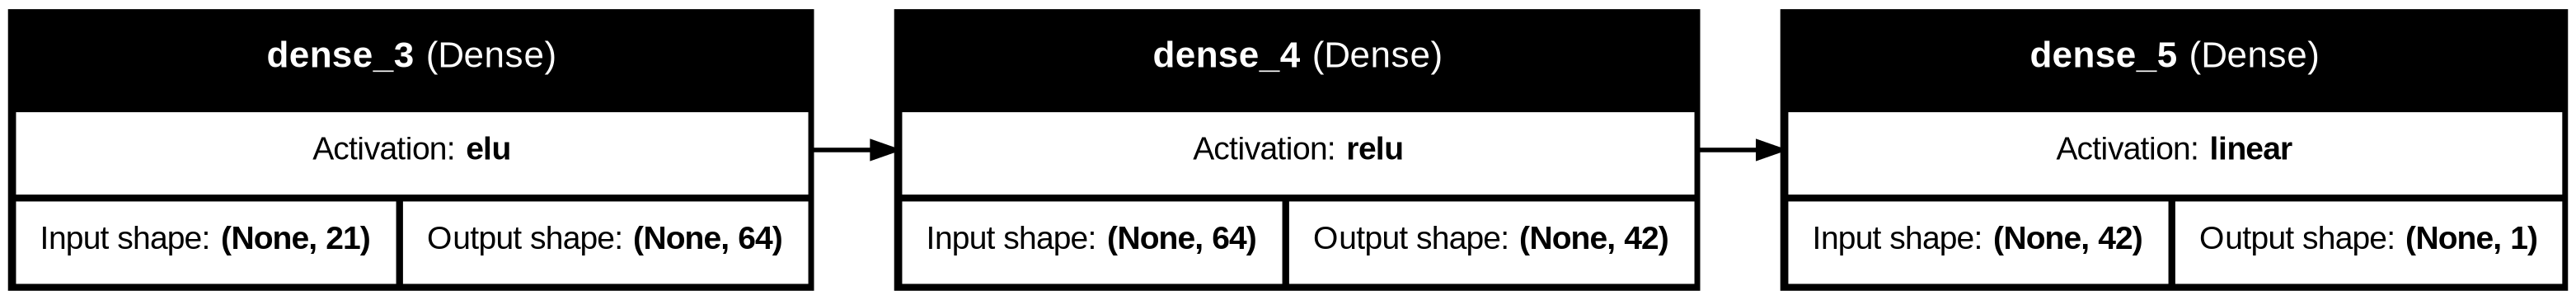

In [62]:
from tensorflow.keras.utils import plot_model

plot_model(model2,show_shapes=True,show_layer_names=True,
           show_layer_activations=True,rankdir='LR')

In [63]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=10,
                           restore_best_weights=True)

In [64]:
from tensorflow.keras.optimizers import Adam

model2.compile(optimizer=Adam(learning_rate=0.005),loss='mse',metrics=['mae'])

history2 = model2.fit(x_train,y_train,epochs=200,batch_size=20,
                    validation_split=0.125, verbose=1, callbacks=early_stop)

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5200 - mae: 2.0340 - val_loss: 0.9970 - val_mae: 0.8060
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7013 - mae: 0.6365 - val_loss: 0.3025 - val_mae: 0.4156
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3126 - mae: 0.4160 - val_loss: 0.2039 - val_mae: 0.3307
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2371 - mae: 0.3564 - val_loss: 0.2108 - val_mae: 0.3431
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2142 - mae: 0.3412 - val_loss: 0.1969 - val_mae: 0.3223
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2172 - mae: 0.3427 - val_loss: 0.1971 - val_mae: 0.3344
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2007 - mae: 0.3315 - val_loss: 0.1797 - val_mae: 0.3101
Epoch 8/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2020 - mae: 0.3300 - val_loss: 0.2067 - val_mae: 0.3430
Epoch 9/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.187

In [65]:
y_pred2 = model2.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [66]:
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred2)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.2653742902486601
MSE: 0.1269456419122329
RMSE: 0.3562943192253181
R2 Score: 0.7604568199607928


# Final Evaluation

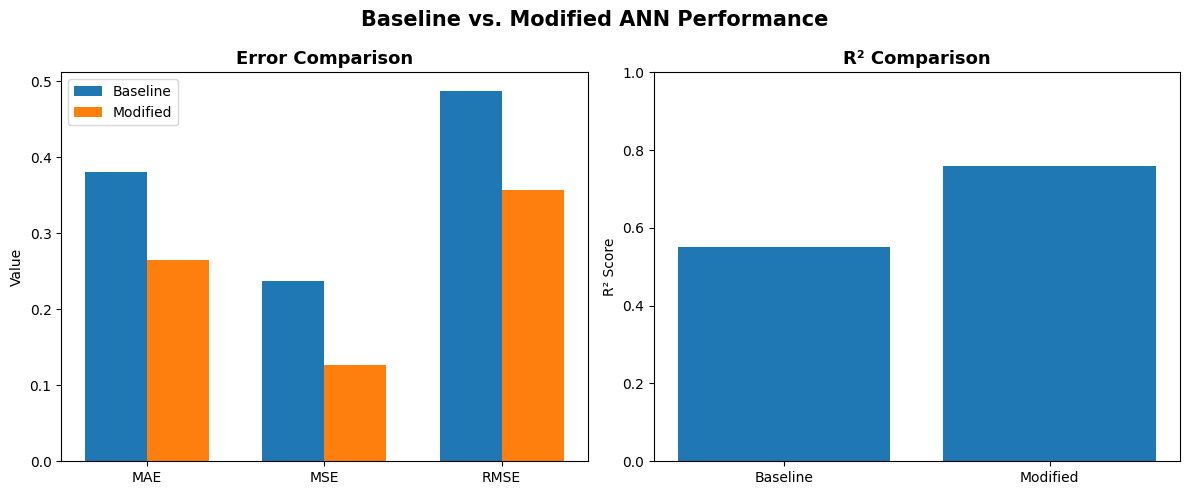

In [76]:
metrics = ['MAE', 'MSE', 'RMSE']
baseline = [0.38056768500687327,0.2373559862111394,0.4871919398051854]
modified = [0.2653742902486601,0.1269456419122329,0.3562943192253181]

r2_baseline = 0.5521153236779244
r2_modified = 0.7604568199607928

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2,baseline,width,label='Baseline')
bars2 = axes[0].bar(x + width/2,modified,width,label='Modified')

axes[0].set_title('Error Comparison',fontsize=13,fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Value')
axes[0].legend()

models = ['Baseline', 'Modified']
r2_values = [r2_baseline, r2_modified]

bars = axes[1].bar(models,r2_values,)

axes[1].set_title('R² Comparison',fontsize=13,fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)

fig.suptitle('Baseline vs. Modified ANN Performance',
             fontsize=15,fontweight='bold')

plt.tight_layout()
plt.show()

Model Baseline

* MAE: 2914.1159296142578
* MSE: 26697682.063769914
* RMSE: 5166.979975166337
* R2 Score: 0.5734682190612049

step - loss: 33086006.0000 - mae: 3071.2698 - val_loss: 21836810.0000 - val_mae: 2617.4346


Model Modifikasi

* MAE: 0.2577260219382274
* MSE: 0.11594650738169117
* RMSE: 0.34050918839539585
* R2 Score: 0.7812119055504709

loss: 0.1127 - mae: 0.2587 - val_loss: 0.2151 - val_mae: 0.3773

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i^{pred} - y_i^{actual} \right|
$$

$$
MSE = \frac{1}{n} \sum (y_{pred} - y_{actual})^2
$$

Terjadi peningkatan pada metric di model modifikasi yaitu:

* MAE berkurang: Model lebih akurat
* RMSE berkurang: Model mampu menangani outlier dengan lebih baik
* R2 bertambah: Model dapat menjelaskan lebih besar variansi data
* train loss > Val loss: model tidak overfit, generalisasi baik